In [23]:
!pip3 install pandas keras tensorflow scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [16]:
import os
import numpy as np
import pandas as pd
from PIL import Image

dataset_path = './stl_data/dataset_output/256x256/'

if "df" not in globals():
    df = pd.read_csv(dataset_path + 'dataset.csv')

records = []
missing_files = []

for _, row in df.iterrows():
    left_path = os.path.join(dataset_path, row["left"])
    right_path = os.path.join(dataset_path, row["right"])

    if not os.path.exists(left_path) or not os.path.exists(right_path):
        missing_files.append((left_path, right_path))
        continue

    left_img = np.asarray(Image.open(left_path).convert("RGB"))
    right_img = np.asarray(Image.open(right_path).convert("RGB"))

    records.append({
        "filename": row["filename"],
        "d": row["d"],
        "o": row["o"],
        "rx": row["rx"],
        "ry": row["ry"],
        "rz": row["rz"],
        "image_left": left_img,
        "image_right": right_img,
        "left_path": left_path,
        "right_path": right_path,
    })

if missing_files:
    print(f"{len(missing_files)} missing image files for some rows:", missing_files)

dataset = records
left_images = np.stack([item["image_left"] for item in dataset])
right_images = np.stack([item["image_right"] for item in dataset])
csv_values = np.stack([[item["d"], item["o"], item["rx"], item["ry"], item["rz"]] for item in dataset])

print(f"Left images shape: {left_images.shape}")
print(f"Right images shape: {right_images.shape}")
print(f"CSV values shape: {csv_values.shape}")

Left images shape: (159, 256, 256, 3)
Right images shape: (159, 256, 256, 3)
CSV values shape: (159, 5)


In [17]:
import tensorflow as tf

image_size = (256, 256)
input_shape = image_size + (3,)

def image_branch(input_tensor):
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(input_tensor)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dense(32 * 32 * 8, activation="relu")(x)
    x = tf.keras.layers.Reshape((32, 32, 8))(x)
    x = tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    return x

input_image_1 = tf.keras.Input(shape=input_shape, name="image_1")
input_image_2 = tf.keras.Input(shape=input_shape, name="image_2")

branch_1 = image_branch(input_image_1)
branch_2 = image_branch(input_image_2)

combined = tf.keras.layers.Concatenate()([branch_1, branch_2])
output_d = tf.keras.layers.Dense(1, activation="linear", name="d")(combined)

model = tf.keras.Model(inputs=[input_image_1, input_image_2], outputs=output_d)
model.compile(optimizer="adam", loss="mse")

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_1             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_2             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │        896 │ image_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │        896 │ image_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 128, 128,  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 524288)    │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 524288)    │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │ 67,108,992 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │ 67,108,992 │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8192)      │  1,056,768 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 8192)      │  1,056,768 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 32, 32, 8) │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 32, 32, 8) │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      1,168 │ reshape_2[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      1,168 │ reshape_3[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 16384)     │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 16384)     │          0 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │  1,048,640 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │  1,048,640 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ dense_8[0][0],  

 Total params: 138,433,057 (528.08 MB)

 Trainable params: 138,433,057 (528.08 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# normalize image data for training
left_images = left_images.astype("float32") / 255.0
right_images = right_images.astype("float32") / 255.0

# target is the "d" value
y = csv_values[:, 0].astype("float32")

# normalize image data for training
left_images = left_images.astype("float32") / 255.0
right_images = right_images.astype("float32") / 255.0

# target is the "d" value
y = csv_values[:, 0].astype("float32")

X_train_left, X_test_left, X_train_right, X_test_right, y_train, y_test = train_test_split(
    left_images, right_images, y, test_size=0.2, random_state=42, shuffle=True
)

history = model.fit(
    [X_train_left, X_train_right],
    y_train,
    epochs=10,
    batch_size=20,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step - loss: 278439.1875 - val_loss: 104120.6719
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 101365.4297 - val_loss: 40690.5977
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 68943.7500 - val_loss: 31921.5293
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 47261.0469 - val_loss: 26316.1699
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 47959.9688 - val_loss: 34027.6094
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 39881.2656 - val_loss: 32843.5898
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 37269.2656 - val_loss: 37998.7891
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - loss: 49445.7930 - val_loss: 22875.9902
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - loss: 35898.6016 - val_loss: 23748.5938
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - loss: 34442.4453 - val_loss: 23050.1895


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Test accuracy: 0.0312
Test weighted F1 score: 0.0208
Confusion matrix:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Test accuracy: 0.0312
Test weighted F1 score: 0.0208
Confusion matrix:


<Figure size 800x600 with 0 Axes>

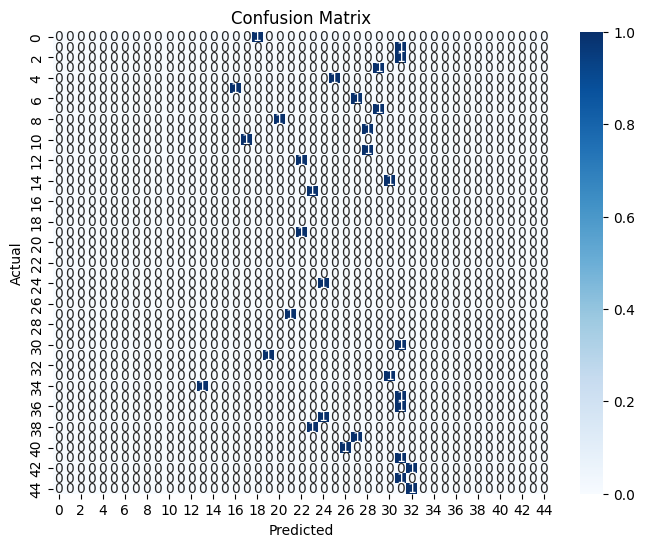

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict([X_test_left, X_test_right]).flatten()

# convert regression outputs to discrete labels for accuracy / f1 / confusion matrix
y_test_cls = np.rint(y_test).astype(int)
y_pred_cls = np.rint(y_pred).astype(int)

acc = accuracy_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls, average="weighted")
cm = confusion_matrix(y_test_cls, y_pred_cls)

print(f"Test accuracy: {acc:.4f}")
print(f"Test weighted F1 score: {f1:.4f}")
print("Confusion matrix:")

plt.figure(figsize=(8, 6))
import matplotlib.pyplot as plt

y_pred = model.predict([X_test_left, X_test_right]).flatten()

# convert regression outputs to discrete labels for accuracy / f1 / confusion matrix
y_test_cls = np.rint(y_test).astype(int)
y_pred_cls = np.rint(y_pred).astype(int)

acc = accuracy_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls, average="weighted")
cm = confusion_matrix(y_test_cls, y_pred_cls)

print(f"Test accuracy: {acc:.4f}")
print(f"Test weighted F1 score: {f1:.4f}")
print("Confusion matrix:")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()